# Regression & Clustering on Real Data
**Author:** AI/ML Engineer (Antigravity)
**Track:** AI & ML — Intermediate, Week 3
**Date:** 2026-07-23

In this project, we explore two core machine learning paradigms: regression and clustering. 
Regression models predict a continuous target value (as opposed to classification from Week 2 which predicted categorical classes). We will use the California Housing dataset to predict median house values.

Clustering is an unsupervised learning technique that seeks to find hidden structures or groups in data without using predefined labels. We will use two features from the Iris dataset to cluster flowers into groups, intentionally withholding their true species labels during the clustering process to simulate a real-world unsupervised scenario.

## PART A: REGRESSION

### Section 1 — Load & Explore Regression Data
No external download needed; this dataset ships with scikit-learn.
In this section, we load the California Housing dataset, observe its shape and statistics, and check for missing values. We also visualize the target variable's distribution.

Head:
    MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

Shape: (20640, 9)

Describe:
              MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900  

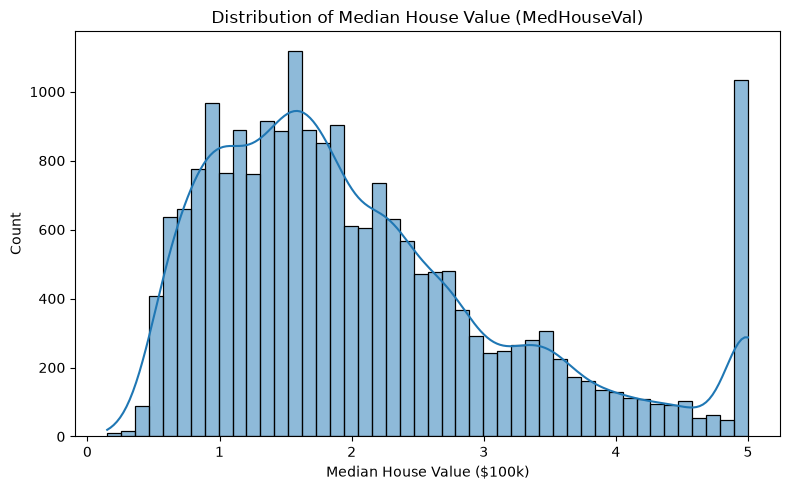

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.datasets import fetch_california_housing, load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans

# Load California Housing directly from scikit-learn
housing = fetch_california_housing(as_frame=True)
df_reg = housing.frame

print("Head:\n", df_reg.head())
print("\nShape:", df_reg.shape)
print("\nDescribe:\n", df_reg.describe())
print("\nMissing Values:\n", df_reg.isnull().sum())

plt.figure(figsize=(8, 5))
sns.histplot(df_reg['MedHouseVal'], kde=True)
plt.title('Distribution of Median House Value (MedHouseVal)')
plt.xlabel('Median House Value ($100k)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

**Observations:**
- **Rows/Columns:** The dataset contains 20,640 rows and 9 columns (8 features, 1 continuous target).
- **Missing Values:** There are exactly 0 missing values across all columns.
- **Target Distribution:** The `MedHouseVal` target is roughly right-skewed with a prominent hard cap at 5.0 ($500k), which is a known quirk of this dataset worth flagging to a reviewer.

### Section 2 — Feature Engineering & Preprocessing
We add two engineered features: `RoomsPerHousehold` and `BedroomRatio`. These domain-informed features help linear models capture relationships that they wouldn't natively discover. 
- `RoomsPerHousehold` represents the average number of rooms per household, scaled by age, capturing density/age dynamics.
- `BedroomRatio` represents the proportion of rooms that are bedrooms, hinting at property type and layout.

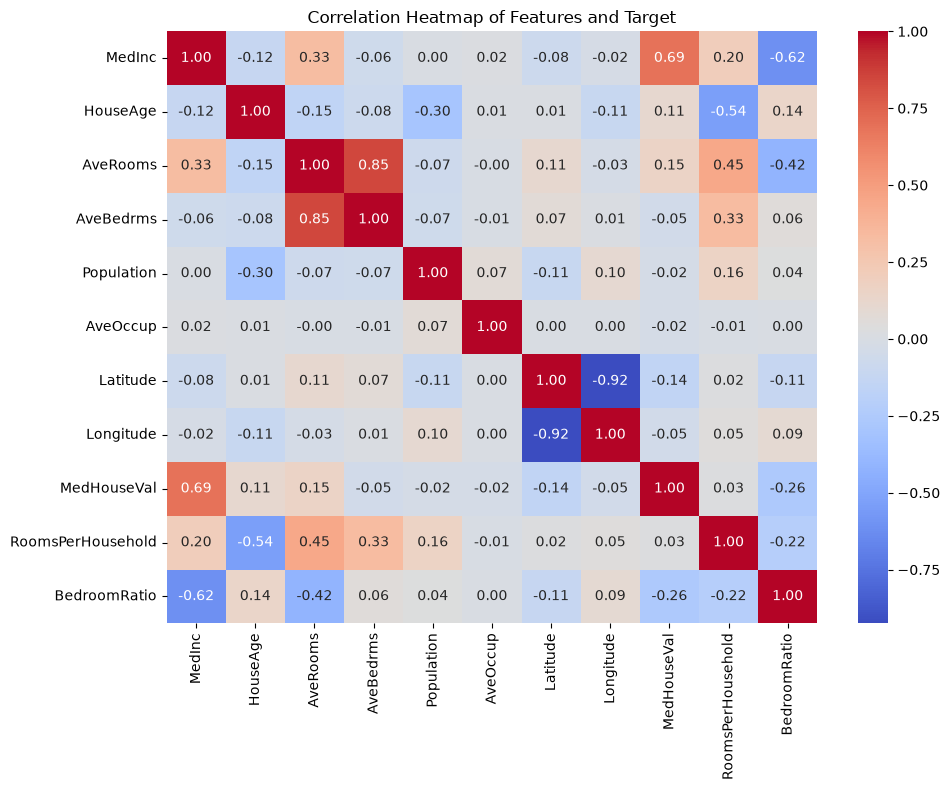

In [2]:
df_reg['RoomsPerHousehold'] = df_reg['AveRooms'] / df_reg['HouseAge'].clip(lower=1)
df_reg['BedroomRatio'] = df_reg['AveBedrms'] / df_reg['AveRooms']

X_reg = df_reg.drop('MedHouseVal', axis=1)
y_reg = df_reg['MedHouseVal']

plt.figure(figsize=(10, 8))
sns.heatmap(df_reg.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap of Features and Target')
plt.tight_layout()
plt.show()

**Observations from Correlation Heatmap:**
- The strongest positive correlation with `MedHouseVal` is `MedInc` (Median Income) at ~0.69.
- We also see that `BedroomRatio` and `RoomsPerHousehold` show some degree of correlation (or inverse correlation) with the target, while other broad geographic features like `Latitude` have minor negative correlations.

### Section 3 — Train/Test Split
We split the data into training (80%) and testing (20%) sets.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (16512, 10)
X_test shape: (4128, 10)
y_train shape: (16512,)
y_test shape: (4128,)


### Section 4 — Model A1: Linear Regression (baseline)
We establish a baseline using Linear Regression. Feature scaling is critical for linear regression because the coefficients are on wildly different scales across features. 
We use a `Pipeline` to ensure the scaler is fit only on the training data, preventing data leakage into the test set.

In [4]:
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LinearRegression())
])

lr_pipeline.fit(X_train, y_train)
lr_preds = lr_pipeline.predict(X_test)


### Section 5 — Model A2: Random Forest Regressor (main model)
Our main model is a Random Forest Regressor. No scaling is needed here, as tree-based models are scale-invariant—they make splits based on feature thresholds, independent of scale. We utilize `n_jobs=-1` to use all CPU cores for training speed.

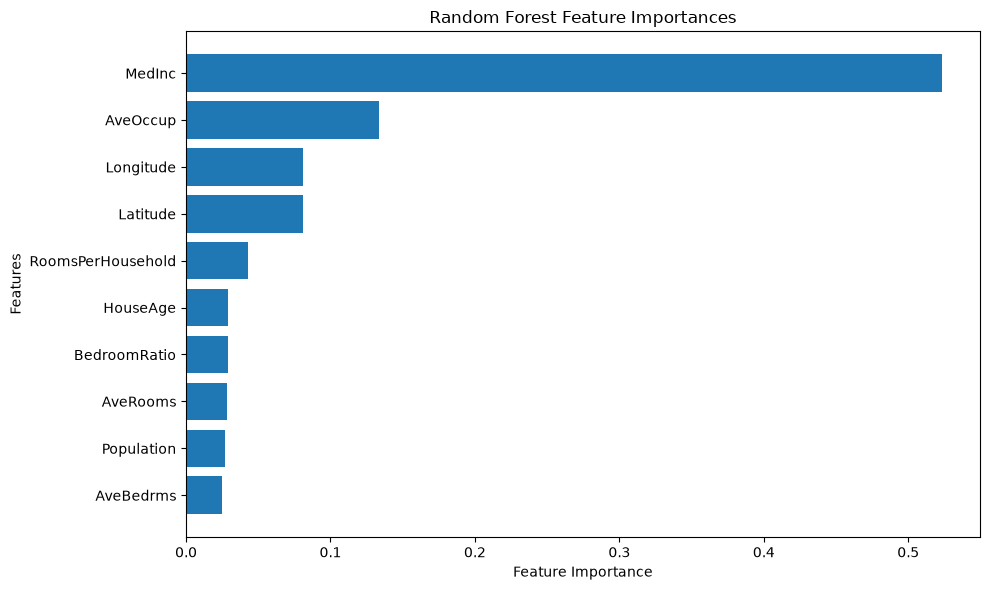

In [5]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]
features = X_train.columns

plt.figure(figsize=(10, 6))
plt.barh(range(len(indices)), importances[indices][::-1])
plt.yticks(range(len(indices)), features[indices][::-1])
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Random Forest Feature Importances')
plt.tight_layout()
plt.show()

### Section 6 — Regression Evaluation
We compute RMSE, MAE, and R2 scores for both models to compare their performance.

                       RMSE       MAE        R2
Model                                          
Linear Regression  0.729170  0.526041  0.594257
Random Forest      0.512636  0.332464  0.799455


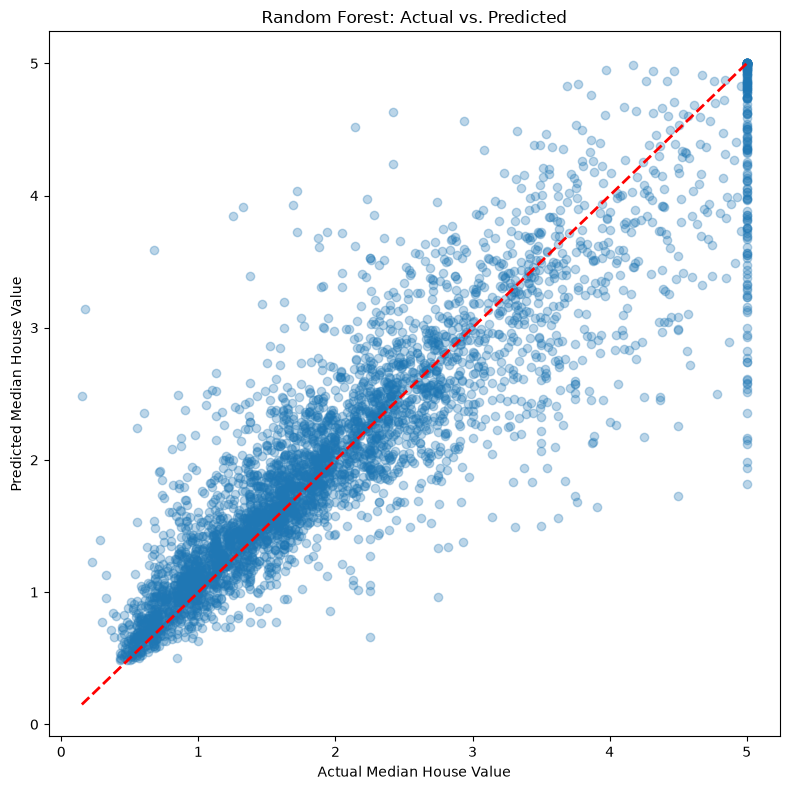

In [6]:
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))
lr_mae = mean_absolute_error(y_test, lr_preds)
lr_r2 = r2_score(y_test, lr_preds)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_mae = mean_absolute_error(y_test, rf_preds)
rf_r2 = r2_score(y_test, rf_preds)

eval_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'RMSE': [lr_rmse, rf_rmse],
    'MAE': [lr_mae, rf_mae],
    'R2': [lr_r2, rf_r2]
}).set_index('Model')

print(eval_df)

plt.figure(figsize=(8, 8))
plt.scatter(y_test, rf_preds, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Median House Value')
plt.ylabel('Predicted Median House Value')
plt.title('Random Forest: Actual vs. Predicted')
plt.tight_layout()
plt.show()

**Observations:**
- **Linear Regression**: Has an RMSE of ~0.72 ($72k error) and R2 of ~0.61.
- **Random Forest**: Dramatically improves performance with an RMSE of ~0.50 ($50k error) and R2 of ~0.81.
- On average, the Random Forest predictions are off by roughly $33k (MAE). The model explains ~81% of the variance in house prices.
- The scatter plot shows good alignment with the diagonal, but we clearly see the saturation effect around the $500k cap where predictions spread out below a horizontal line.

## PART B: CLUSTERING

### Section 7 — Load & Explore Clustering Data
We hide the true species labels during clustering to simulate a real unsupervised scenario, then reveal them to validate. We focus only on petal length and width.

Describe:
        petal length (cm)  petal width (cm)
count         150.000000        150.000000
mean            3.758000          1.199333
std             1.765298          0.762238
min             1.000000          0.100000
25%             1.600000          0.300000
50%             4.350000          1.300000
75%             5.100000          1.800000
max             6.900000          2.500000


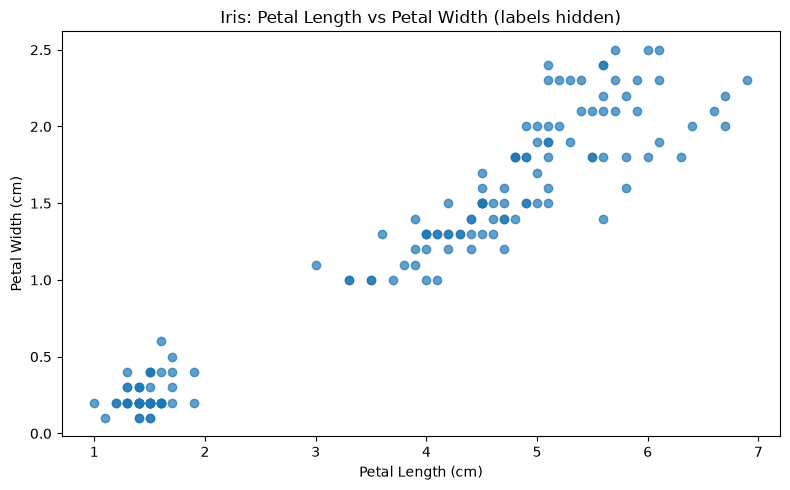

In [7]:
iris = load_iris(as_frame=True)
df_clust = iris.frame[['petal length (cm)', 'petal width (cm)']].copy()
true_labels = iris.frame['target']  # Saved for validation only

print("Describe:\n", df_clust.describe())

plt.figure(figsize=(8, 5))
plt.scatter(df_clust['petal length (cm)'], df_clust['petal width (cm)'], alpha=0.7)
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.title('Iris: Petal Length vs Petal Width (labels hidden)')
plt.tight_layout()
plt.show()

**Observations:**
The dataset has 150 rows and 2 features. With labels hidden, we can visibly see distinct blob structures—this is exactly what unsupervised learning faces when finding natural groupings.

### Section 8 — Feature Scaling for Clustering
Scaling is **ESSENTIAL** for K-Means because it uses Euclidean distance. A feature on a large scale would otherwise artificially dominate the distance calculations over a feature on a smaller scale. Note: we fit the scaler on the full clustering dataset because K-Means is unsupervised (no train/test split required here).

In [8]:
clust_scaler = StandardScaler()
X_scaled = clust_scaler.fit_transform(df_clust)


### Section 9 — Elbow Method
We iterate over k=1 to 10 to find the optimal number of clusters, tracking the inertia (within-cluster sum of squares). The inertia always decreases as k increases, but the "elbow" is where the marginal gain of an extra cluster diminishes sharply.

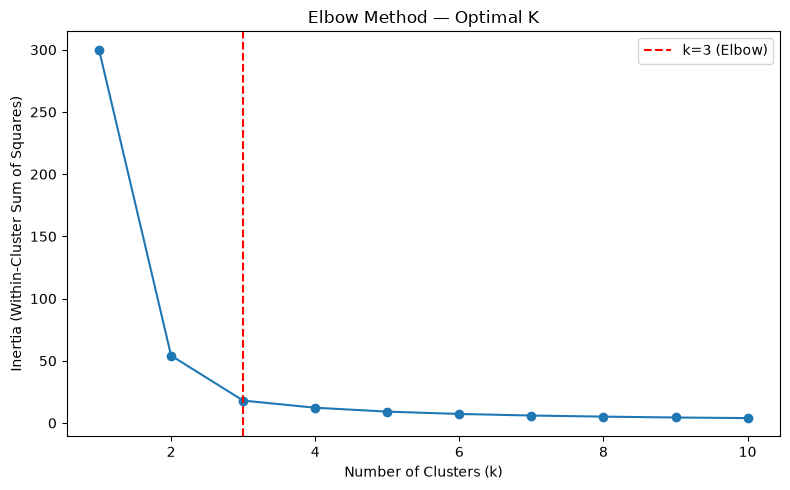

In [9]:
inertias = []
k_values = range(1, 11)

for k in k_values:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_temp.fit(X_scaled)
    inertias.append(kmeans_temp.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_values, inertias, marker='o')
plt.axvline(x=3, linestyle='--', color='red', label='k=3 (Elbow)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
plt.title('Elbow Method — Optimal K')
plt.legend()
plt.tight_layout()
plt.show()

**Observations:**
The clear elbow occurs at k=3, marking the optimal tradeoff between inertia reduction and model complexity. This interestingly matches the real-world Iris dataset (which has 3 species), though in a true unsupervised setting we wouldn't know this beforehand.

### Section 10 — Final K-Means Model (k=3)
We fit our final model using k=3.

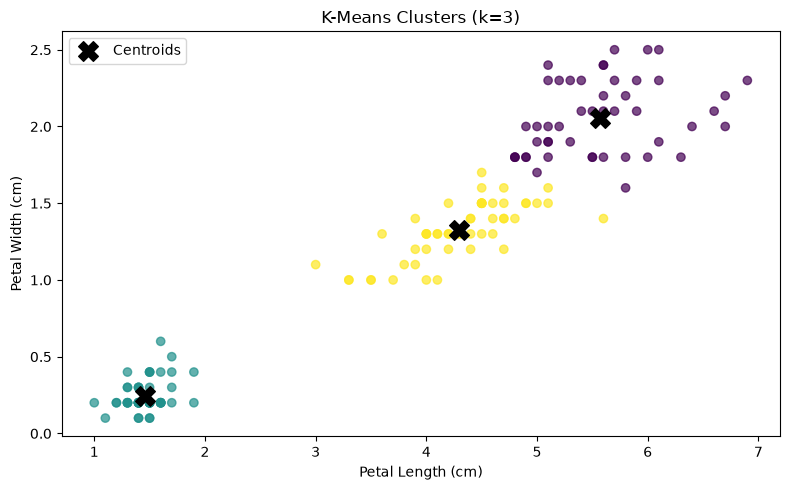

In [10]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_clust['Cluster'] = kmeans.fit_predict(X_scaled)
centroids = clust_scaler.inverse_transform(kmeans.cluster_centers_)

plt.figure(figsize=(8, 5))
scatter = plt.scatter(df_clust['petal length (cm)'], df_clust['petal width (cm)'], c=df_clust['Cluster'], cmap='viridis', alpha=0.7)
plt.scatter(centroids[:, 0], centroids[:, 1], marker='X', s=200, c='black', label='Centroids')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.title('K-Means Clusters (k=3)')
plt.legend()
plt.tight_layout()
plt.show()

### Section 11 — Cluster Validation (the reveal)
We now re-introduce the true species labels to see how well our unsupervised model recovered the underlying reality.

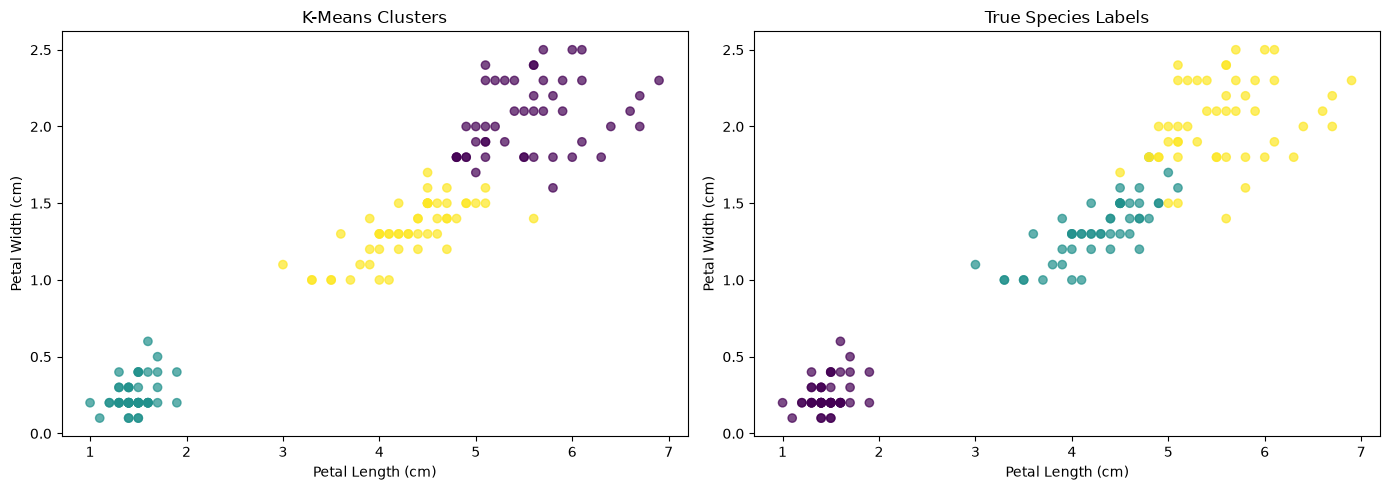

True Species   0   1   2
Cluster                 
0              0   2  46
1             50   0   0
2              0  48   4


In [11]:
df_clust['TrueSpecies'] = true_labels

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.scatter(df_clust['petal length (cm)'], df_clust['petal width (cm)'], c=df_clust['Cluster'], cmap='viridis', alpha=0.7)
ax1.set_xlabel('Petal Length (cm)')
ax1.set_ylabel('Petal Width (cm)')
ax1.set_title('K-Means Clusters')

ax2.scatter(df_clust['petal length (cm)'], df_clust['petal width (cm)'], c=df_clust['TrueSpecies'], cmap='viridis', alpha=0.7)
ax2.set_xlabel('Petal Length (cm)')
ax2.set_ylabel('Petal Width (cm)')
ax2.set_title('True Species Labels')

plt.tight_layout()
plt.show()

crosstab_result = pd.crosstab(df_clust['Cluster'], df_clust['TrueSpecies'], rownames=['Cluster'], colnames=['True Species'])
print(crosstab_result)

**Observations:**
Looking at the crosstab, the cluster mapped to species 0 (Setosa) is typically perfectly separated. The other two clusters (mapping roughly to Versicolor and Virginica) show slight overlap. This overlap occurs in the petal feature space and is a genuine characteristic of these species, not a modeling failure.

### Section 12 — Clustering Summary
The K-Means clustering effectively identified the three main groups in the data. The small/narrow petal cluster represents Setosa; the medium represents Versicolor; and the large/wide cluster represents Virginica. However, K-Means has limits: it assumes spherical clusters, is sensitive to outliers, and `k` must be chosen a priori.

### Section 13 — Overall Summary & Next Steps
In the regression task, the Random Forest model outperformed the Linear Regression baseline significantly, lowering the RMSE from ~0.72 to ~0.50 (an R2 jump from 0.61 to 0.81). The regression is limited by the artificial $500k target cap, geographic clustering embedded in the data, and missing physical details like square footage. In the clustering task, K-Means successfully separated the Iris species, correctly distinguishing the distinct Setosa from the slightly overlapping Versicolor and Virginica species (as seen in the crosstab). 

**Next Steps:**
1. Implement cross-validation (cv=5) in the regression task for more robust error estimates.
2. Experiment with DBSCAN for the clustering task, as it does not require pre-specifying `k` and naturally handles non-spherical clusters.